<a href="https://colab.research.google.com/github/sarthakshukla74/IOT_FAULT_DETECTION_RUL_PRED/blob/main/IOT_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/factory_sensor_simulator_2040.csv")

In [ ]:
df.head()

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  object 
 1   Machine_Type                500000 non-null  object 
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 13  AI_Supervision

In [ ]:
df.describe()

,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
count,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,15156.000000,30340.000000,45624.000000,45214.000000,500000.000000
mean,2019.962360,50012.424764,59.997682,9.99114,75.003477,69.456568,64.114159,149.922161,182.257866,5.003128,2.000588,3.000840,452.422338,74.995513,119.917514,39.984794,499.760966,0.602098
std,11.829812,28861.849078,14.986973,4.99953,9.990791,18.847444,23.152998,79.955937,105.552537,2.238043,1.413087,1.730541,288.971269,10.035133,15.017048,9.989653,50.012057,1.203647
min,2000.000000,0.000000,-15.730000,-17.82000,23.650000,0.000000,0.000000,-222.740000,0.000000,0.000000,0.000000,0.000000,0.000000,34.970000,52.680000,-0.160000,296.440000,0.000000
25%,2010.000000,25055.000000,49.890000,6.62000,68.270000,56.540000,48.130000,96.090000,91.000000,3.000000,1.000000,2.000000,200.000000,68.250000,109.820000,33.200000,465.940000,0.000000
50%,2020.000000,49973.000000,60.000000,10.00000,75.000000,70.030000,65.010000,149.950000,182.000000,5.000000,2.000000,3.000000,451.000000,74.950000,119.860000,40.030000,499.770000,0.000000
75%,2030.000000,74995.000000,70.050000,13.36000,81.730000,83.540000,81.840000,203.900000,274.000000,6.000000,3.000000,4.000000,700.000000,81.682500,130.072500,46.750000,533.307500,1.000000
max,2040.000000,100000.000000,127.330000,32.47000,120.700000,100.000000,100.000000,544.200000,365.000000,18.000000,12.000000,13.000000,1133.000000,114.320000,185.380000,80.790000,694.170000,11.000000


In [ ]:
df.isna().sum()

,0
Machine_ID,0
Machine_Type,0
Installation_Year,0
Operational_Hours,0
Temperature_C,0
Vibration_mms,0
Sound_dB,0
Oil_Level_pct,0
Coolant_Level_pct,0
Power_Consumption_kW,0


In [ ]:
df.drop('Hydraulic_Pressure_bar', axis=1, inplace=True)

In [ ]:
df.drop('Coolant_Flow_L_min',axis=1,inplace=True)

In [ ]:
df.drop('Heat_Index',axis=1,inplace=True)

In [ ]:
df.drop('Laser_Intensity',axis=1,inplace=True)

In [ ]:
df.isna().sum()

,0
Machine_ID,0
Machine_Type,0
Installation_Year,0
Operational_Hours,0
Temperature_C,0
Vibration_mms,0
Sound_dB,0
Oil_Level_pct,0
Coolant_Level_pct,0
Power_Consumption_kW,0


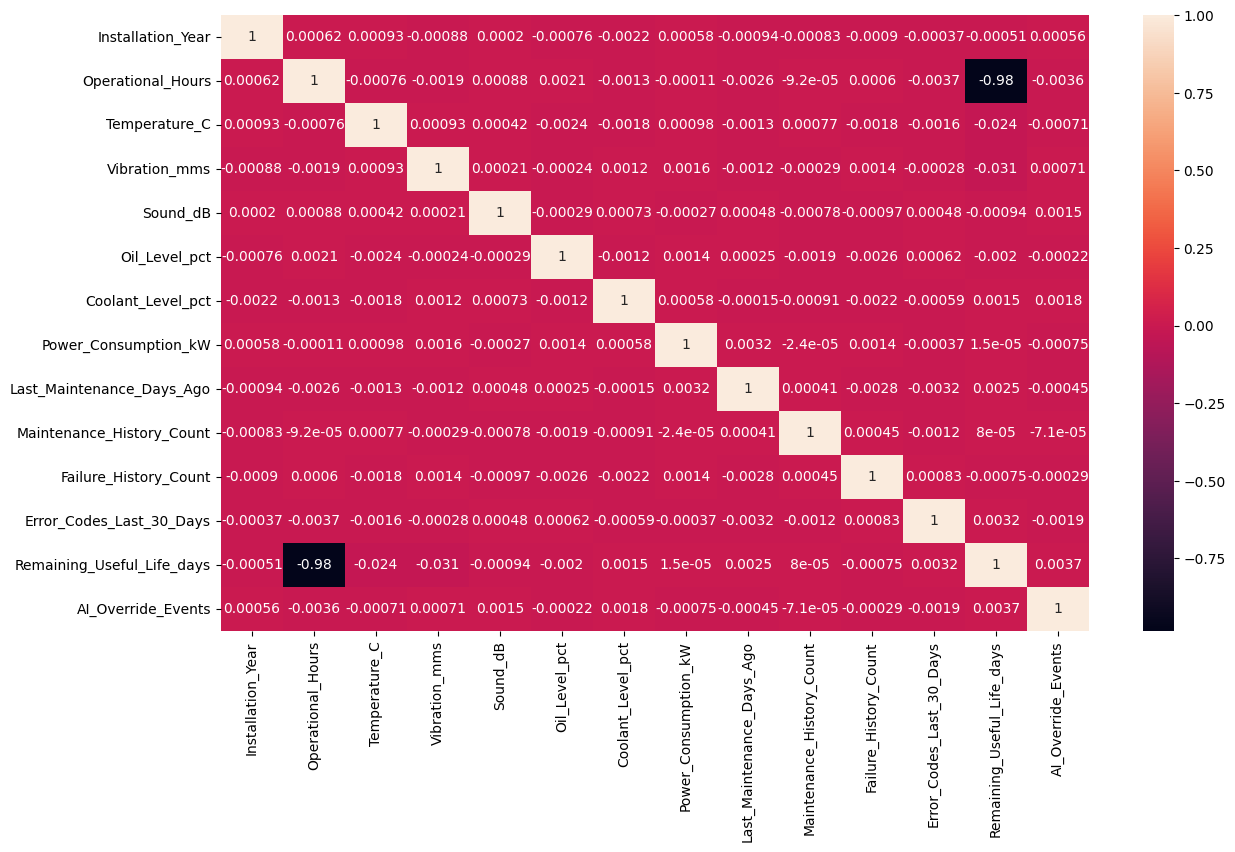

In [ ]:
plt.figure(figsize=(14,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(data=numeric_df.corr(), annot=True)
plt.show()

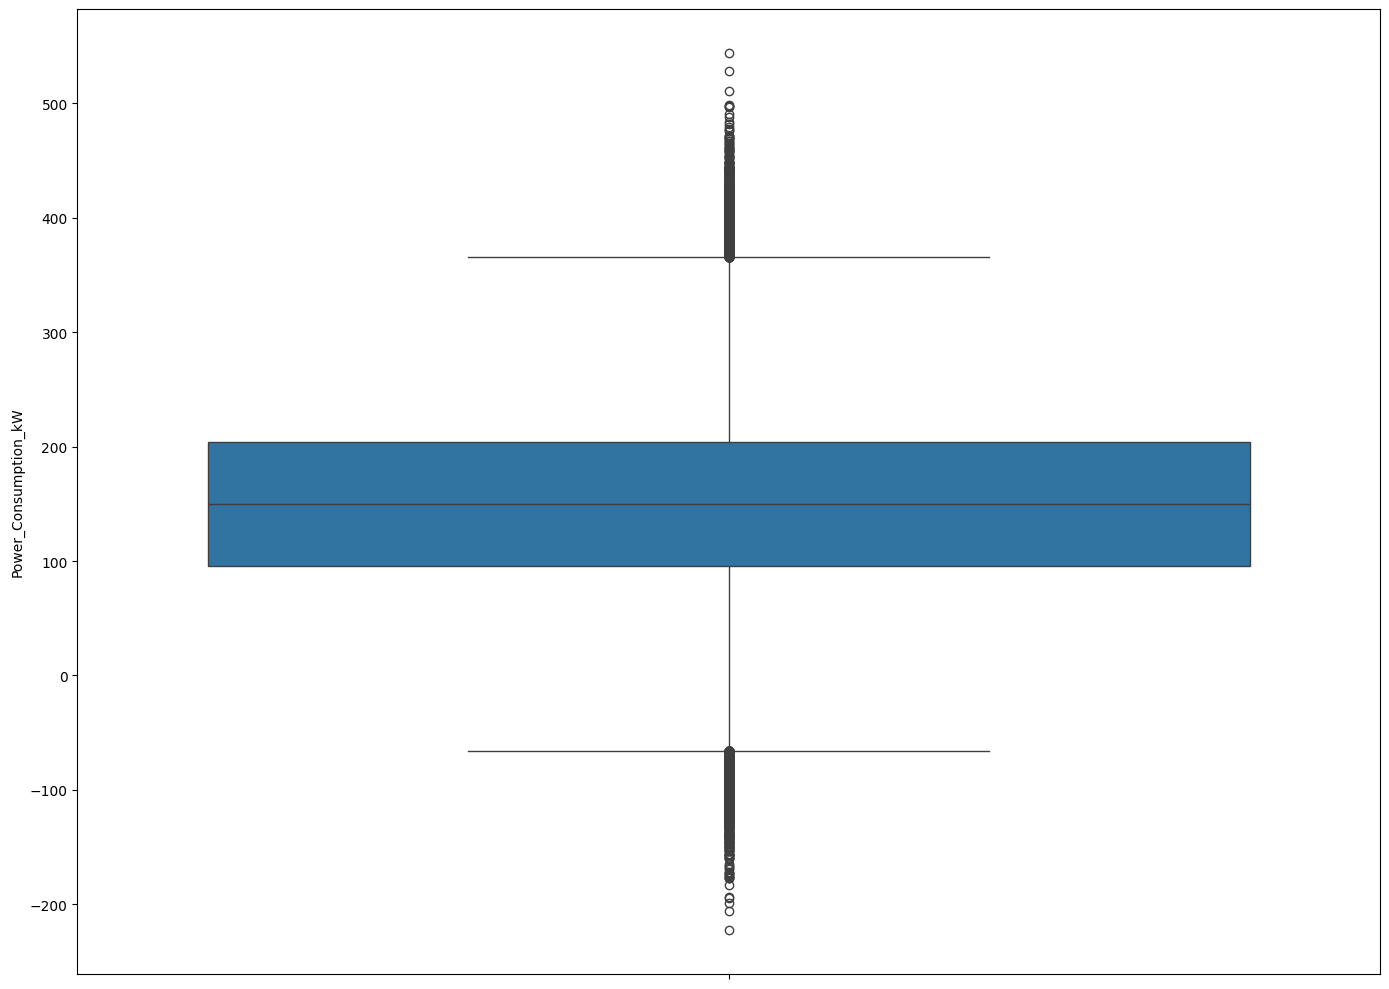

In [ ]:
plt.figure(figsize=(14,10))
sns.boxplot(data=df['Power_Consumption_kW'])
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,True,3,162.0,False,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,True,4,147.0,False,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,True,6,0.0,True,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,False,4,161.0,False,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,False,1,765.0,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,282,4,3,False,0,820.0,False,0
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,208,4,1,False,4,34.0,False,0
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,185,7,2,False,4,815.0,False,0
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,274,3,2,True,0,99.0,False,2


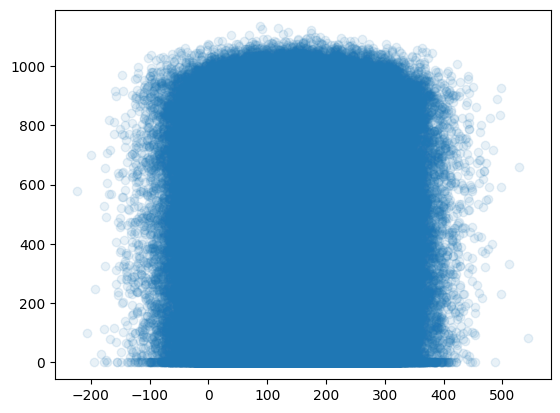

In [ ]:
plt.scatter(df['Power_Consumption_kW'],df['Remaining_Useful_Life_days'],alpha=0.1)
plt.show()

In [ ]:
df_x=df.drop('Remaining_Useful_Life_days',axis=1)
df_y=df['Remaining_Useful_Life_days']

In [ ]:
def cap_sensor_data(df):
  df_capped=df.copy()
  numeric_cols=df_capped.select_dtypes(include=[np.number]).columns
  for col in numeric_cols:
    skewness=df_capped[col].skew()
    if -0.5<skewness<0.5:
      mean=df_capped[col].mean()
      std=df_capped[col].std()
      ul=mean+3*std
      ll=mean-3*std
      df_capped[col]=np.where(df_capped[col]>ul,ul,np.where(df_capped[col]<ll,ll,df_capped[col]))
    else:
      q1=df_capped[col].quantile(0.25)
      q3=df_capped[col].quantile(0.75)
      iqr=q3-q1
      ul=q3+1.5*iqr
      ll=q1-1.5*iqr
      df_capped[col]=np.where(df_capped[col]>ul,ul,np.where(df_capped[col]<ll,ll,df_capped[col]))
  return df_capped

In [ ]:
df_final=cap_sensor_data(df_x)

In [ ]:
df_final.shape

(500000, 17)

In [ ]:
# 1. Update your sensor list based on your actual columns
active_sensors = ['Vibration_mms', 'Sound_dB', 'Temperature_C', 'Power_Consumption_kW','Maintenance_History_Count','Failure_History_Count','Error_Codes_Last_30_Days']

# 2. Use a slightly larger window (30 to 50) to catch longer trends
window = 30

for col in active_sensors:
    # Mean: Is the machine getting louder/hotter on average?
    df_final[f'{col}_roll_mean'] = df.groupby('Machine_ID')[col].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean())

    # Std: Is the vibration/sound becoming unstable (jittery)?
    df_final[f'{col}_roll_std'] = df.groupby('Machine_ID')[col].transform(
        lambda x: x.rolling(window=window, min_periods=1).std())



# 4. Fill NaNs
df_final.fillna(0, inplace=True)

In [ ]:
for col in active_sensors:
    df_final[f'{col}_delta'] = df_final[col] - df_final[f'{col}_roll_mean']

In [ ]:
df_final=pd.get_dummies(df_final,columns=['Machine_Type'],drop_first=True)

In [ ]:
df_final.drop("Machine_ID",axis=1,inplace=True)

In [ ]:
current_year=df['Installation_Year'].max();
df_final['Machine_age']=current_year-df['Installation_Year'];

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df_final,df_y,test_size=0.2,random_state=42)

In [ ]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
print(f"R2 Score:{r2_score(y_test,y_pred)}")
print(f"MSE:{mean_squared_error(y_test,y_pred)}")

R2 Score:0.9721047726885743
MSE:2324.5877504180003


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
rf=RandomForestRegressor(random_state=42)
param_dist={
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
     'max_features':['sqrt','log2',None],
    'bootstrap':[True,False]
}


In [ ]:
random_search=RandomizedSearchCV(estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='r2')
# Create a smaller sample for the search
X_train_sample = X_train.sample(frac=0.1, random_state=42)
y_train_sample = y_train.sample(frac=0.1, random_state=42)

# Run random_search on the sample
random_search.fit(X_train_sample, y_train_sample)
print(f"Best Parameters: {random_search.best_params_}")
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)


print(f"Final R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Final MAE: {mean_absolute_error(y_test, y_pred):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None, 'bootstrap': True}
Final R2 Score: 0.9717
Final MAE: 37.4589


In [ ]:
import lightgbm as lgb
lgb_model=lgb.LGBMRegressor(n_estimators=1000,learning_rate=0.05,random_state=42)
lgb_model.fit(X_train,y_train)
y_pred=lgb_model.predict(X_test)
print(f"R2 Score:{r2_score(y_test,y_pred)}")
print(f"MSE:{mean_squared_error(y_test,y_pred)}")
print(f"MAR:{mean_absolute_error(y_test,y_pred)}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2214
[LightGBM] [Info] Number of data points in the train set: 400000, number of used features: 48
[LightGBM] [Info] Start training from score 452.276693
R2 Score:0.9728923361544974
MSE:2258.9578716891883
MAR:36.77337591736629


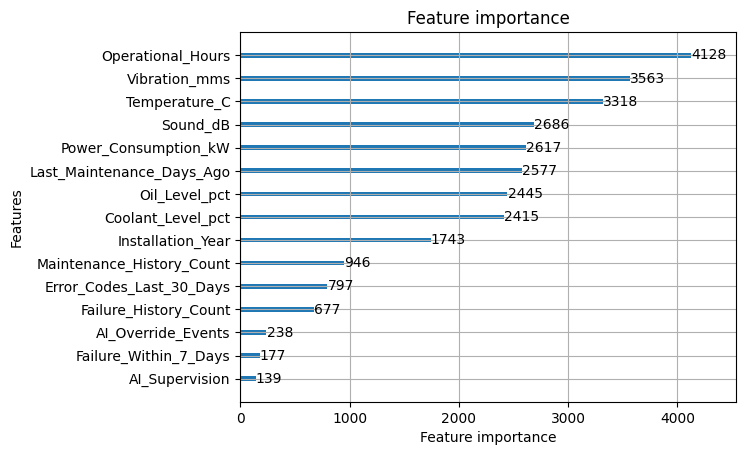

In [ ]:
lgb.plot_importance(lgb_model, max_num_features=15)
plt.show()